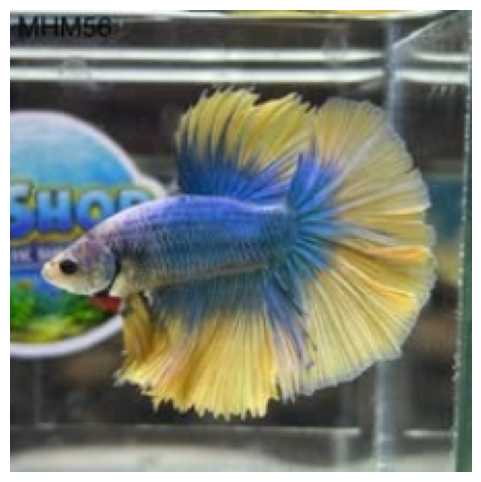

In [19]:
import cv2
import matplotlib.pyplot as plt

# 1. Define the specific image path
image_path = "data/augmented/images/test_Copy of 652634738_952495470637312_3579218559049832291_n.jpg" 

# 2. Load and verify the image
raw_img = cv2.imread(image_path)
if raw_img is None:
    raise FileNotFoundError(f"OpenCV could not find the image at: {image_path}. Check your working directory.")

# 3. Convert from OpenCV's BGR format to standard RGB for plotting
rgb_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

# 4. Display the raw image
plt.figure(figsize=(6, 6))
plt.imshow(rgb_img)
plt.axis('off') # Hide the axis numbers for a cleaner presentation
plt.show()

In [20]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import config
from model import MFLDNet

# Setup Device & Load Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MFLDNet(
    num_keypoints=config.NUM_KEYPOINTS,
    embed_dim=512,
    num_blocks=12, # Fixed to match your training architecture
    kernel_size=config.KERNEL_SIZE,
    dropout_rate=0.0,
    heatmap_size=config.HEATMAP_SIZE,
).to(device)

# Load specific trained weights here (Direct load)
model.load_state_dict(torch.load("best.pth", map_location=device))
model.eval()

# Load and preprocess image
image_path = "data/augmented/images/test_Copy of 652634738_952495470637312_3579218559049832291_n.jpg" 
raw_img = cv2.imread(image_path)    

if raw_img is None:
    raise FileNotFoundError(f"OpenCV could not find the image at: {image_path}. Check your working directory.")

rgb_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
orig_h, orig_w = rgb_img.shape[:2]

#PREPARE DATA FOR NEXT CELL
resized = cv2.resize(rgb_img, (config.INPUT_SIZE, config.INPUT_SIZE))
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

# Finish normalization and convert to a PyTorch Tensor
norm_img = (resized.astype(np.float32) / 255.0 - mean) / std
input_tensor = torch.from_numpy(norm_img.transpose(2, 0, 1)).float().unsqueeze(0).to(device)

print(f"Original Image Size: {orig_w}x{orig_h}")
print(f"Input Tensor Shape: {input_tensor.shape}")

Original Image Size: 224x224
Input Tensor Shape: torch.Size([1, 3, 224, 224])


Shape after Patch Embedding: torch.Size([1, 512, 56, 56])
Shape after multiple Isometric ConvBlocks: torch.Size([1, 512, 56, 56])


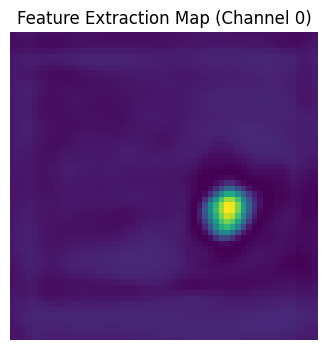

In [21]:
# Pass through Patch Embedding
with torch.no_grad():
    features = model.patch_embedding(input_tensor)
    print(f"Shape after Patch Embedding: {features.shape}")
    
    # Pass through the   ConvBlocks
    features = model.conv_blocks(features)
    print(f"Shape after multiple Isometric ConvBlocks: {features.shape}")

plt.figure(figsize=(4, 4))
plt.imshow(features[0, 0].cpu().numpy(), cmap='viridis')
plt.title("Feature Extraction Map (Channel 0)")
plt.axis('off')
plt.show()

Shape after Heatmap Conv: torch.Size([1, 13, 56, 56]) -> (Batch, Keypoints, H, W)


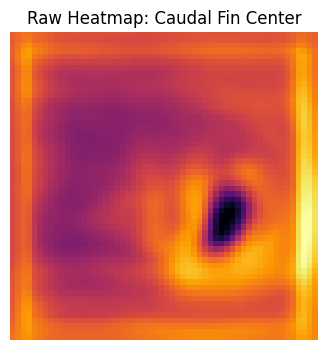

In [22]:
# Pass through the Heatmap Convolution
with torch.no_grad():
    heatmap = model.heatmap_conv(features)
    print(f"Shape after Heatmap Conv: {heatmap.shape} -> (Batch, Keypoints, H, W)")

# Visualize the heatmap for the Caudal Fin Center (Keypoint 12)
kp_index = 12 
plt.figure(figsize=(4, 4))
plt.imshow(heatmap[0, kp_index].cpu().numpy(), cmap='inferno')
plt.title(f"Raw Heatmap: {config.KEYPOINT_NAMES[kp_index]}")
plt.axis('off')
plt.show()

Final Coordinate Output Shape: torch.Size([1, 13, 2]) -> (Batch, Keypoints, (X,Y))


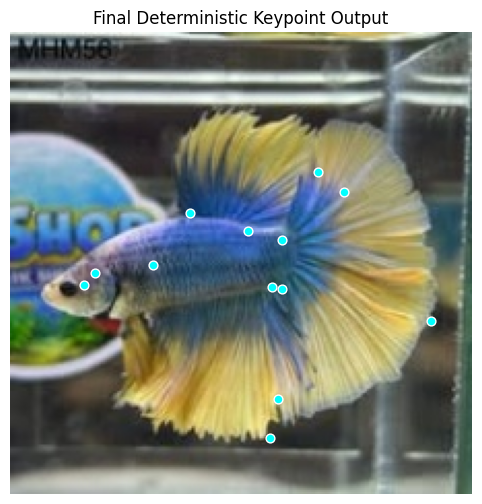

In [23]:
# Pass through the Soft-Argmax Head
with torch.no_grad():
    coords = model.soft_argmax(heatmap)
    print(f"Final Coordinate Output Shape: {coords.shape} -> (Batch, Keypoints, (X,Y))")

# Scale back to original image size for plotting
pred_coords = coords[0].cpu().numpy()
pred_coords[:, 0] *= orig_w
pred_coords[:, 1] *= orig_h

# Plot final coordinates on original image
plt.figure(figsize=(8, 6))
plt.imshow(rgb_img)
plt.scatter(pred_coords[:, 0], pred_coords[:, 1], c='cyan', s=40, edgecolors='white', label='Predictions')
plt.title("Final Deterministic Keypoint Output")
plt.axis('off')
plt.show()